# pexl Python model: read, inspect, modify, export

This notebook demonstrates the basic workflow of the Python-side PEExcel model:

1. Read an Excel export into the `Project` / `District` / `Scenario` model
2. Inspect the hierarchical structure
3. Access scenario values and schema metadata
4. Modify a scenario value in Python
5. Write the updated project back to a new Excel file

The example uses an existing PEExcel export workbook as input.

In [39]:
%load_ext autoreload
%autoreload 2
from pexl import Project


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Read an example project workbook

We start by reading an existing Excel export.  
This creates a `Project` object with nested `District` and `Scenario` objects.

In [40]:
from pathlib import Path

project = Project.from_excel(Path("../data/exports/ka_project_backup_v1_11_4.xlsx"))
project

<Project districts=28 warnings=66 source='..\\data\\exports\\ka_project_backup_v1_11_4.xlsx'>

## 2. Basic project overview

The project object is the top-level container.  
It stores:

- the source file path
- all districts
- warnings collected during import

In [ ]:
print(project)
print("District count:", len(project.districts))
print("Warning count:", len(project.warnings))

<Project districts=28 warnings=66 source='..\\data\\exports\\ka_project_backup_v1_11_4.xlsx'>
District count: 28
Warning count: 66


In [42]:
project.warnings[:10]

["Column 'Default': district name 'Default' does not match project_name='AT_GWBg'",
 "Column 'Default': scenario name 'Default' does not match project_scenario_name='nach 2020 - existing - Erdgas'",
 "Column 'Gründerzeit | Ausgangslage Gas': district name 'Gründerzeit' does not match project_name='AT_GWBg'",
 "Column 'Gründerzeit | Ausgangslage Gas': scenario name 'Ausgangslage Gas' does not match project_scenario_name='nach 2020 - existing - Erdgas'",
 "Column 'Gründerzeit | thermisch Saniert + Fernwärme': scenario name 'thermisch Saniert + Fernwärme' does not match project_scenario_name='Ausgangslage Gas'",
 "Column 'AT_EFHo | bis 1944 - existing - Erdgas': district name 'AT_EFHo' does not match project_name='Neues Projekt'",
 "Column 'AT_EFHo | bis 1944 - existing - Erdgas': scenario name 'bis 1944 - existing - Erdgas' does not match project_scenario_name='Ausgangsvariante'",
 "Column 'Südtiroler Siedlung | Planung': district name 'Südtiroler Siedlung' does not match project_name='N

The warning list is useful for identifying inconsistencies between:

- scenario column names in Excel
- values stored inside the imported scenario itself  
  (for example `project_name` or `project_scenario_name`)

## 3. Navigate the hierarchy

The data model is intentionally simple:

- `Project` contains multiple `District`s
- each `District` contains multiple `Scenario`s
- each `Scenario` contains values (`scenario.v`) and metadata (`scenario.meta`)

In [43]:
project.districts[:10]

[<District 'Default' scenarios=1>,
 <District 'Gründerzeit' scenarios=3>,
 <District 'Volksschule Neubau' scenarios=1>,
 <District 'Wohnen Neubau 2.5 Geschosse' scenarios=1>,
 <District 'mg. Wohnbau 90er Sanierung' scenarios=1>,
 <District 'Mischnutzung Neubau 7-stöckig' scenarios=1>,
 <District 'AT_EFHo' scenarios=1>,
 <District 'Südtiroler Siedlung' scenarios=1>,
 <District 'EFHo' scenarios=5>,
 <District 'EFHk' scenarios=5>]

Districts and Scenarios can be directly accessed from the parent by their name, or by their index in the list:

In [44]:
district = project["EFHo"]
district2 = project.districts[1]
district, district2

(<District 'EFHo' scenarios=5>, <District 'Gründerzeit' scenarios=3>)

In [45]:
district.scenarios

[<Scenario 'bis 1944 - existing - Erdgas'>,
 <Scenario '1945 - 1989 - existing - Erdgas'>,
 <Scenario '1990 - 1999 - existing - Erdgas'>,
 <Scenario '2000 - 2020 - existing - Erdgas'>,
 <Scenario 'nach 2020 - existing - Erdgas'>]

In [46]:
s0 = district["bis 1944 - existing - Erdgas"]
s4 = district["nach 2020 - existing - Erdgas"]

s0, s4

(<Scenario 'bis 1944 - existing - Erdgas'>,
 <Scenario 'nach 2020 - existing - Erdgas'>)

## 4. Access scenario values directly

All variables can be accessed via dot notation on `scenario.v`.

This is the most direct interface when the variable name or parts of it is known .

In [47]:
print("Project/district name:", s0.v.project_name)
print("Scenario:", s0.name)
print("Description:", s0.v.project_description)
print("Total GFA:", s0.v.GFA_total, s0.meta.GFA_total.unit)

Project/district name: EFHo
Scenario: bis 1944 - existing - Erdgas
Description: Einstöckiges Einfamilienhaus /offene Bauweise
Total GFA: 171.48 m²


The schema metadata is available in parallel via `scenario.meta`.

This is helpful for labels, units, semantic grouping, and generic downstream tooling.

In [48]:
s0.meta.GFA_total

<VarMeta 🏙️ GFA_total [m²] @IN>

In [49]:
vars(s0.meta.GFA_total)

{'var_name': 'GFA_total',
 'attr_name': 'GFA_total',
 'icon': '🏙️',
 'label_de': 'BGF Quartier',
 'unit': 'm²',
 'comment': None,
 'source': 'IN',
 'ka': 0,
 'domain': 'usage',
 'measure': 'area',
 'spatial_scope': 'GFA',
 'temporal_scope': None,
 'entity_group': None,
 'entity_key': None}

## 5. Use `ScenarioView` for structured access

The `ScenarioView` API provides filtered, metadata-aware access to scenario variables.

Useful entry points are:

- `scenario.view` → all variables
- `scenario.inn` → input variables
- `scenario.out` → output variables

In [50]:
s0.inn

<ScenarioView('bis 1944 - existing - Erdgas', n=607, source=IN)>

In [51]:
s0.inn.domains()

['Battery',
 'Construction',
 'Cooling',
 'DHW',
 'Flexibility',
 'GHG',
 'Heating',
 'Mobility',
 'PV',
 'Solar Gains',
 'Space Use',
 'Thermal Hull',
 'Ventilation',
 'assessment',
 'declaration',
 'district',
 'geometry',
 'lca',
 'mobility',
 'primary_energy',
 'project',
 'tool',
 'usage']

In [52]:
s0.inn.entity_groups()

['component',
 'cooling',
 'dhw',
 'energy_carrier',
 'heating',
 'hull',
 'mobility',
 'usage']

In [53]:
usage_view = s0.inn.by(entity_group="usage", entity_key="residential")
usage_view

<ScenarioView('bis 1944 - existing - Erdgas', n=25, source=IN, filters={ entity_group='usage', entity_key='residential' })>

In [54]:
usage_view.to_var_dict()

{'GFA_residential': 171.48,
 'NFA_to_GFA_ratio_residential': 0.8,
 'NFA_residential': 137.184,
 'renovation_ratio_residential': 0,
 'rh_residential': 2.65,
 'fc_residential': 1,
 'illuminance_min_residential': 300,
 'vent_share_mechanical_residential': 0,
 'vent_night_residential': 'geöffnet',
 'vent_ach_max_residential': 0.40000000000005964,
 'vent_scale_residential': 1.000000000000149,
 'Ev_scale_residential': 1,
 'vent_heat_recovery_winter_residential': 0,
 'vent_heat_recovery_summer_residential': 0,
 'usage_concurrency_winter_residential': 1,
 'usage_concurrency_summer_residential': 1,
 'DHW_demand_residential_kWhm2': 15.975,
 'aux_el_demand_residential_kWhm2': 1.7520000000002613,
 'Plugloads_scale_residential': 1.3,
 'density_NFApPers_residential': 41.7,
 'cool_share_residential': 0,
 'DHW_1_share_residential': 1,
 'DHW_occupancy_residential': 41.7,
 'DHW_concurrency_residential': 0.1,
 'StatPAX_residential': 3.28978417266187}

In [55]:
s0.inn.by(domain="PV").to_var_dict()


{'PV_is_used': 0,
 'PV_profile_name': 'Roof tilt: 15° (Vienna)',
 'PV_id': 41,
 'PV_scale': 9.3,
 'PV_efficiency': 0.9,
 'PV_m2_per_kWp': 5,
 'PV_kWp': 9.3,
 'PV_module_area': 46.5}

This is especially useful for generic processing tasks such as:

- selecting all variables of a certain entity group
- plotting grouped inputs
- exporting subsets
- comparing scenarios

In [56]:
s0.out.domains()

['comfort',
 'energy_end_use',
 'final_energy',
 'heat_balance',
 'primray_energy',
 'weather']

<Axes: >

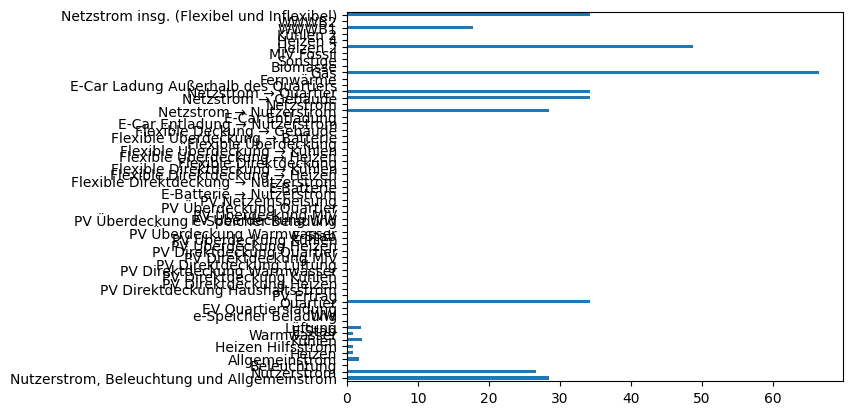

In [ ]:
final_energy = s4.out.by(domain="final_energy")
import pandas
diagram_components = {meta.label_de: value for meta, value in final_energy.items()}
pandas.Series(diagram_components).plot(kind="barh")


## 6. Compare two scenarios

Since all scenarios share the same schema-defined variables, comparisons are straightforward.


In [58]:
d0 = s0.inn.to_var_dict()
d1 = s4.inn.to_var_dict()

for var_name, v0 in d0.items():
    v1 = d1.get(var_name)
    if v0 != v1:
        print(f"{var_name:50s}  {v0!r}   {v1!r}")

NFV_u                                               363.5376   0
NFV_c                                               0   363.5376
hull_ext_wall_wo_window_m2                          147.67714282119744   138.33731979538058
hull_windows_north_m2                               1.1678200609094762   2.251730177200232
hull_windows_east_m2                                2.7762031708487998   5.352931215251476
hull_windows_south_m2                               3.3426307761955014   6.445087596916252
hull_windows_west_m2                                2.7762031708487998   5.352931215251476
hull_window_m2                                      10.062857178802577   19.402680204619436
hull_fenestration_rate                              0.06379394686701266   0.12300418539761275
hull_m2                                             500.70000000000005   500.7
hull_transmittance_walls                            1.3499999999999999   0.08
hull_transmittance_roof                             1.2750000000000001 

## 7. Modify a scenario in Python

Next, we change one input value directly in the Python object model.

For demonstration, we modify one usage area input in one scenario.

In [59]:
scenario_edit = district["nach 2020 - existing - Erdgas"]

print("Before:", scenario_edit.v.GFA_office)

Before: 0


In [60]:
scenario_edit.v.GFA_office = 250.0

print("After:", scenario_edit.v.GFA_office)

After: 250.0


Because the model stores values as Python attributes, direct modification is simple.

In a larger workflow, this can be combined with:

- scripted scenario generation
- parameter sweeps
- batch edits
- consistency checks before export

## 9. Create a new project

In [61]:
from pexl.model.project import Project


new_project = Project()
new_project

<Project districts=0 warnings=0>

In [62]:
from pexl.model.district import District
new_district = District("New District")


In [63]:

new_project.add_district(new_district)
new_project.districts

[<District 'New District' scenarios=0>]

Note that by default, adding a district with a preexisting name will result in a value error,unless `overwrite = True`

In [64]:
new_project.add_district(new_district, overwrite=True)
new_project.districts

[<District 'New District' scenarios=0>]

In [65]:
new_district.add_scenario(scenario_edit, overwrite=True)


In [66]:
print(new_district.scenarios)
print(f"{new_district.scenarios[0].v.GFA_office  =}")

[<Scenario 'nach 2020 - existing - Erdgas'>]
new_district.scenarios[0].v.GFA_office  =250.0


## 8. Write the modified project back to Excel

We now export the full project back to an Excel workbook.

The current writer creates an Excel-style `IN` sheet with:

- schema/meta columns first
- one scenario column per scenario
- scenario column names in the form  
  `district_name | scenario_name`

In [67]:
new_project.to_excel("../data/exports/new_project.xlsx")

WindowsPath('../data/exports/new_project.xlsx')

In [68]:

output_path = Path("../data/exports/new_project.xlsx")

write_project_excel(
    new_project,
    output_path,
    include_derived=True,
    include_meta=True,
)



NameError: name 'write_project_excel' is not defined